In [2]:
import pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import sklearn.model_selection as m

import sklearn


np.set_printoptions(precision=3)
%lsmagic
%matplotlib inline
import matplotlib

matplotlib.use("module://ipykernel.pylab.backend_inline")

In [3]:
!pip install yellowbrick



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
df = pd.read_csv('../data/raw/diabetes.csv')

---

## Correlation Analysis (Initial Dataset)

1. **Objective**:
   - To analyze and identify relationships between features.
   - Detect multicollinearity among features to aid in feature selection.

2. **Steps**:
   - Load a raw dataset (diabetes dataset) into a Pandas DataFrame.
   - Compute a correlation matrix with features like `Insulin`, `BMI`, `BloodPressure`, and more.
   - Visualize correlations using a heatmap to identify highly correlated features that may contribute to multicollinearity.
   - Configure labels and utilize correlation visualizers (from `yellowbrick`) to understand the relationship between features and a target variable (`Age`).

---



In [5]:
# Calculate and display correlation matrix with better formatting
correlation_matrix = df.corr().round(3)
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                          Pregnancies  Glucose  BloodPressure  SkinThickness  \
Pregnancies                     1.000    0.129          0.141         -0.082   
Glucose                         0.129    1.000          0.153          0.057   
BloodPressure                   0.141    0.153          1.000          0.207   
SkinThickness                  -0.082    0.057          0.207          1.000   
Insulin                        -0.074    0.331          0.089          0.437   
BMI                             0.018    0.221          0.282          0.393   
DiabetesPedigreeFunction       -0.034    0.137          0.041          0.184   
Age                             0.544    0.264          0.240         -0.114   
Outcome                         0.222    0.467          0.065          0.075   

                          Insulin    BMI  DiabetesPedigreeFunction    Age  \
Pregnancies                -0.074  0.018                    -0.034  0.544   
Glucose                  

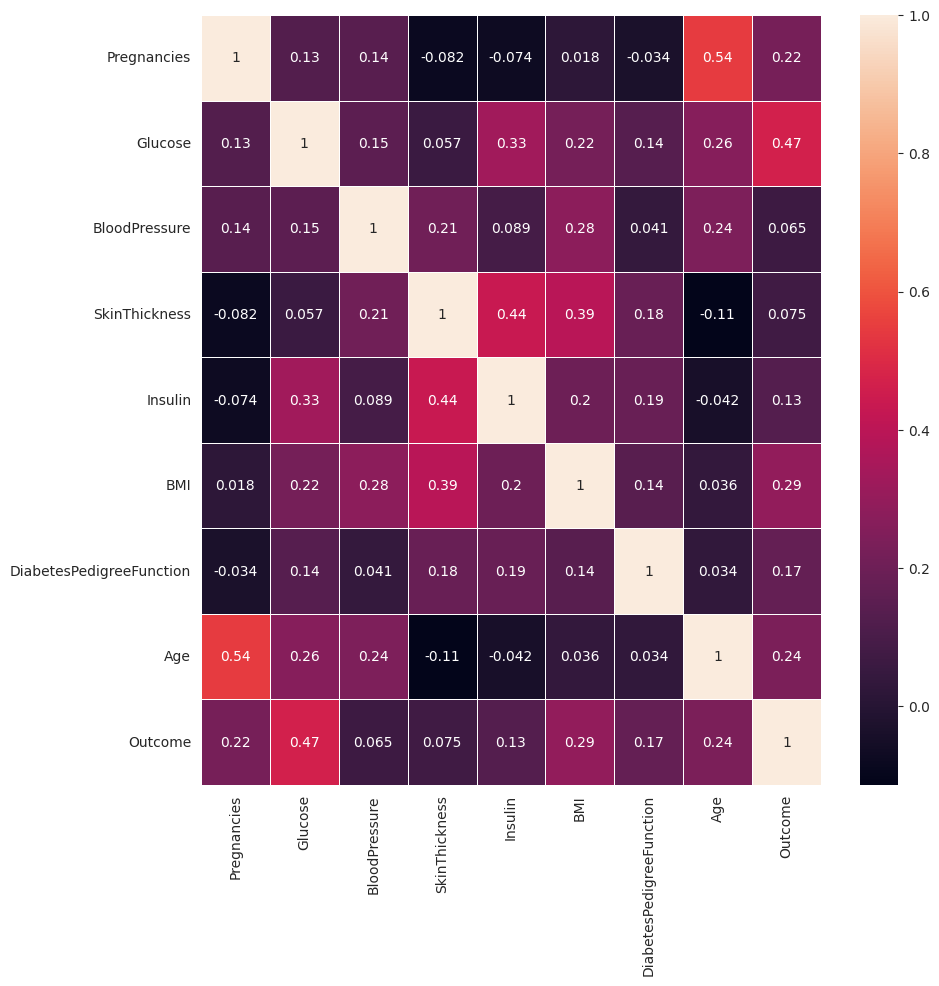

In [6]:
# Visualize correlations with a heatmap

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(df.corr(), annot=True, linewidths=.5, ax=ax)

plt.show()

In [7]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [8]:
X = df[["Insulin", "BMI", "BloodPressure", "DiabetesPedigreeFunction"]]
y = df["Age"]

In [9]:
feature_names = X.columns.to_list()

---

## Feature Importance with Target Correlation

1. **Objective**:
   - To quantify the impact of different features on the target variable through metrics like Pearson correlation or mutual information.

2. **Steps**:
   - Extract specific features and calculate their correlation with the target variable using Yellowbrick's `FeatureCorrelation`.
   - Utilize both continuous and discrete feature handling to distinguish meaningful contributions from each feature.
   - Generate importance plots to facilitate decision-making on feature inclusion.

---


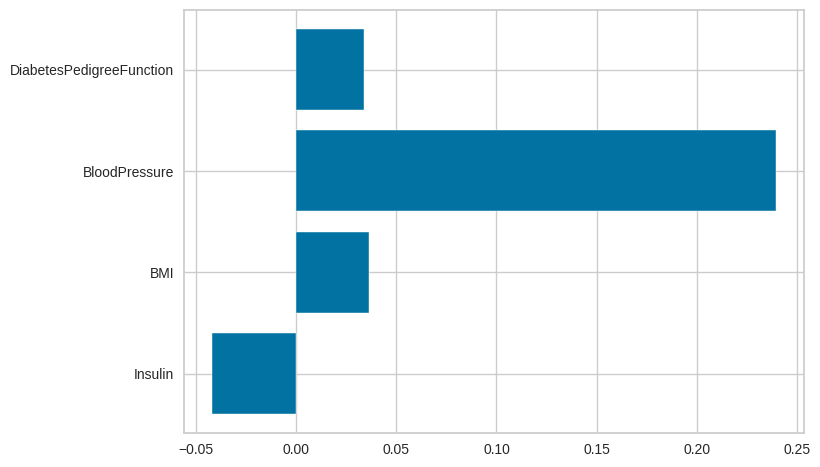

In [10]:
from yellowbrick.target import FeatureCorrelation
# Using Pearson correlation coefficient to measure linear correlation between features and target
visualizer = FeatureCorrelation(labels=feature_names, method="pearson")
visualizer.fit(X, y)
ax = visualizer.ax
plt.sca(ax)
plt.show()

In [11]:
visualizer.scores_

array([-0.042,  0.036,  0.24 ,  0.034])

In [12]:
visualizer.features_

array(['Insulin', 'BMI', 'BloodPressure', 'DiabetesPedigreeFunction'],
      dtype='<U24')

In [13]:
df_ = pd.DataFrame({"feature_names": visualizer.features_, "scores": visualizer.scores_})

In [14]:
df_

,feature_names,scores
0,Insulin,-0.042163
1,BMI,0.036242
2,BloodPressure,0.239528
3,DiabetesPedigreeFunction,0.033561


In [15]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [16]:
feature_names = X.columns.to_list()
feature_names

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [17]:
# Set figure size for better visibility
plt.figure(figsize=(10, 6))
visualizer = FeatureCorrelation(labels=feature_names, method="pearson")

<Figure size 1000x600 with 0 Axes>

In [18]:
visualizer.fit(X, y)

,ax,<Axes: >
,method,'pearson'
,labels,"['Pregnancies', 'Glucose', ...]"
,sort,False
,feature_index,None
,feature_names,None
,color,None


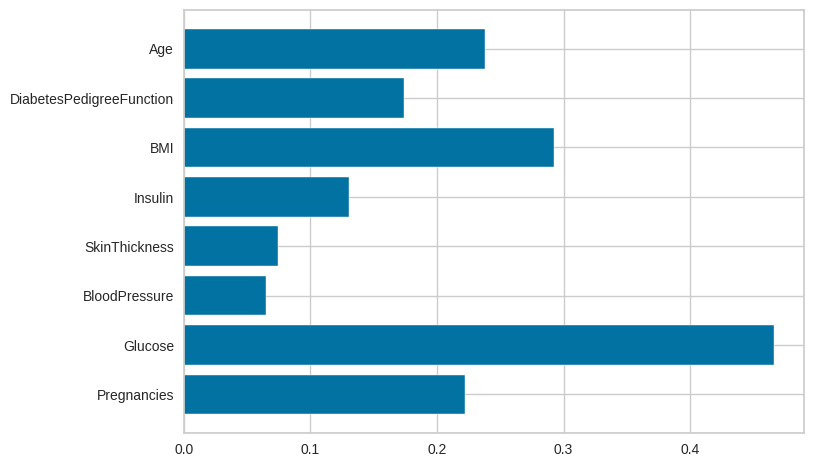

In [19]:
ax = visualizer.ax
plt.sca(ax)
plt.show()

In [20]:
discreet_features = [False for _ in feature_names]
discreet_features[0] = True


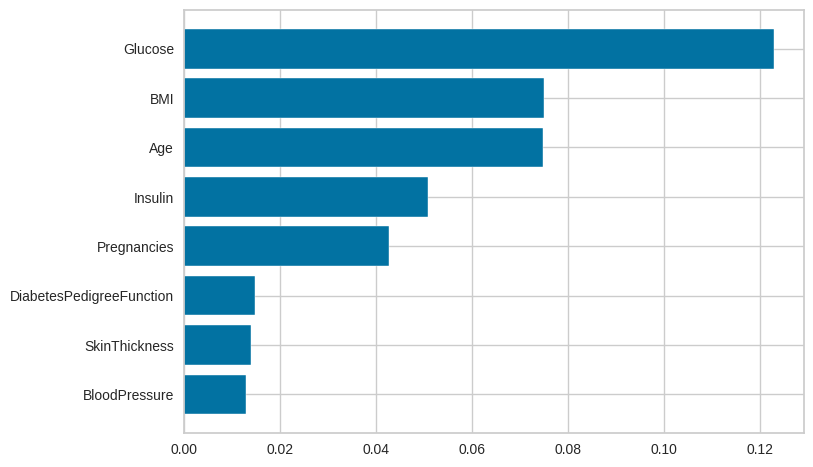

In [21]:
visualizer = FeatureCorrelation(labels=feature_names, method="mutual_info-classification", sort=True)
visualizer.fit(X, y, discrete_features=discreet_features, random_state=42)
ax = visualizer.ax
plt.sca(ax)
plt.show()

In [22]:
visualizer.scores_

array([0.013, 0.014, 0.015, 0.043, 0.051, 0.075, 0.075, 0.123])

---

## Cars Dataset: Processing and Feature Optimization

1. **Objective**:
   - Analyze the `MPG` dataset to create transformations and optimize predictive features.

2. **Steps**:
   - Conduct scaling for numerical columns (`Cylinders`, etc.) for consistency and normalization.
   - Explore and compute descriptive statistics of features.
   - Run a correlation matrix analysis for feature interdependence and target relation.

---


In [23]:
df = pd.read_csv("../data/interim/cars_processed.csv")

In [24]:
df

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Origin,Age
0,18.000000,8,307.0,130,3504,12.0,US,53
1,16.000000,8,304.0,150,3433,12.0,US,53
2,17.000000,8,302.0,140,3449,10.5,US,53
3,14.000000,8,454.0,220,4354,9.0,US,53
4,23.551429,8,440.0,215,4312,8.5,US,53
...,...,...,...,...,...,...,...,...
382,27.000000,4,140.0,86,2790,15.6,US,41
383,44.000000,4,97.0,52,2130,24.6,Europe,41
384,32.000000,4,135.0,84,2295,11.6,US,41
385,28.000000,4,120.0,79,2625,18.6,US,41


In [25]:
from sklearn.preprocessing import scale

In [26]:
# df[["Cylinders"]] = scale(df[["Cylinders"]].astype("float64"))

In [27]:
df_numeric = df.select_dtypes(include='number').drop(columns=["MPG"])

In [28]:
df_numeric.columns


Index(['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration',
       'Age'],
      dtype='object')

In [29]:
for feature in df_numeric.columns:
    df[[feature]] = scale(df[[feature]].astype("float64"))

In [30]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MPG,387.0,2.367251e+01,7.736579,9.000000,17.600000,23.200000,29.000000,46.600000
Cylinders,387.0,3.672055e-17,1.001294,-1.447404,-0.847034,-0.847034,0.353707,1.554447
Displacement,387.0,1.101617e-16,1.001294,-1.199046,-0.865937,-0.445929,0.654779,2.537570
Horsepower,387.0,1.101617e-16,1.001294,-1.513838,-0.752271,-0.305835,0.455733,3.318176
Weight,387.0,1.101617e-16,1.001294,-1.600007,-0.880092,-0.207501,0.738386,2.572779
Acceleration,387.0,2.203233e-16,1.001294,-2.761372,-0.610215,-0.026851,0.538284,3.363956
Age,387.0,8.078522e-16,1.001294,-1.615000,-0.796216,0.022568,0.841351,1.660135


In [31]:
X = df[df_numeric.columns]
y = df["MPG"]
X

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Age
0,1.554447,1.108580,0.692081,0.637231,-1.302961,1.660135
1,1.554447,1.079614,1.217300,0.553231,-1.302961,1.660135
2,1.554447,1.060303,0.954691,0.572161,-1.849865,1.660135
3,1.554447,2.527915,3.055566,1.642864,-2.396769,1.660135
4,1.554447,2.392740,2.924262,1.593174,-2.579071,1.660135
...,...,...,...,...,...,...
382,-0.847034,-0.503862,-0.463401,-0.207501,0.009610,-1.615000
383,-0.847034,-0.919041,-1.356273,-0.988345,3.291036,-1.615000
384,-0.847034,-0.552138,-0.515922,-0.793134,-1.448802,-1.615000
385,-0.847034,-0.696968,-0.647227,-0.402712,1.103418,-1.615000


---

## Regression Modeling (Preliminary)

1. **Objective**:
   - Train and test a linear regression model to predict `MPG` using selected features.

2. **Steps**:
   - Perform a train-test split of data to evaluate the predictive ability of the model.
   - Fit the model on training data and predict outcomes on the test set.
   - Calculate the `R^2` coefficient and use an `adjusted R^2` formula to account for multiple features.

---


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
y_pred = linear_regression.predict(X_test)
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.7875587621496212

In [33]:
def adjusted_r2(r_square, labels, features):
    return 1 - ((1 - r_square) * (len(labels) - 1) / (len(labels) - features.shape[1] - 1))

In [34]:
adjusted_r2(r2_score(y_test, y_pred), y_test, X_test)

0.7696059814862088

---

## Feature Reduction and Validation

1. **Objective**:
   - Eliminate highly correlated features and revalidate model quality with reduced feature sets to improve model interpretability.

2. **Steps**:
   - Drop features (`Cylinders`, `Displacement`) that demonstrate high multicollinearity (correlation > 0.8) with others.
   - Retest the model with reduced feature sets, progressively adding back features for performance monitoring.
   - Repeat the train-test cycle and compute updated `R^2` and `adjusted R^2` values after each iteration.

---
n

In [35]:
X.corr()

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Age
Cylinders,1.000000,0.922633,0.811466,0.873029,-0.458161,0.321850
Displacement,0.922633,1.000000,0.894199,0.932822,-0.526901,0.357047
Horsepower,0.811466,0.894199,1.000000,0.863388,-0.670920,0.404458
Weight,0.873029,0.932822,0.863388,1.000000,-0.397181,0.299049
Acceleration,-0.458161,-0.526901,-0.670920,-0.397181,1.000000,-0.292705
Age,0.321850,0.357047,0.404458,0.299049,-0.292705,1.000000


In [36]:
abs(X.corr()) > 0.8

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Age
Cylinders,True,True,True,True,False,False
Displacement,True,True,True,True,False,False
Horsepower,True,True,True,True,False,False
Weight,True,True,True,True,False,False
Acceleration,False,False,False,False,True,False
Age,False,False,False,False,False,True


In [37]:
trimmed_X = X.drop(columns=["Cylinders", "Displacement", "Weight"])

In [38]:
trimmed_X.corr()

,Horsepower,Acceleration,Age
Horsepower,1.000000,-0.670920,0.404458
Acceleration,-0.670920,1.000000,-0.292705
Age,0.404458,-0.292705,1.000000


In [39]:
X_train, X_test, y_train, y_test = train_test_split(trimmed_X, y, test_size=0.2)

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
y_pred = linear_regression.predict(X_test)
r2_score(y_test, y_pred)


0.6891432970819027

In [40]:
r2 = adjusted_r2(r2_score(y_test, y_pred), y_test, X_test)
r2

0.6765409983149528

In [41]:
trimmed_X["Displacement"] = X["Displacement"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(trimmed_X, y, test_size=0.2)

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
y_pred = linear_regression.predict(X_test)
r_2 = r2_score(y_test, y_pred)

r2_adjusted = adjusted_r2(r2_score(y_test, y_pred), y_test, X_test)


In [43]:
print(r2, r2_adjusted)

0.6765409983149528 0.6628136678565664


In [44]:
trimmed_X["Cylinders"] = X["Cylinders"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(trimmed_X, y, test_size=0.2)

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
y_pred = linear_regression.predict(X_test)
r_2 = r2_score(y_test, y_pred)

r2_adjusted = adjusted_r2(r2_score(y_test, y_pred), y_test, X_test)

print(r2, r2_adjusted)

0.6765409983149528 0.6173628249673715


### VIF - Variance Inflation Factor

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [48]:
vif = pd.DataFrame()

In [49]:
vif["VIF_factor"] = [variance_inflation_factor(X.values, idx) for idx in range(X.shape[1])]

In [51]:
vif['features'] = X.columns

In [53]:
vif.round(2)

,VIF_factor,features
0,6.84,Cylinders
1,16.10,Displacement
2,8.82,Horsepower
3,10.69,Weight
4,2.49,Acceleration
5,1.22,Age


In [54]:
df.columns

Index(['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Origin', 'Age'],
      dtype='object')

In [71]:
X = df.drop(["Displacement", "Weight", "MPG", "Origin"], axis=1)
y = df["MPG"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [72]:
lin = LinearRegression().fit(X_train, y_train)

In [73]:
lin.score(X_train, y_train)

0.7241300392881991

In [74]:
y_pred = lin.predict(X_test)


In [75]:
r2_score(y_test, y_pred)

0.7253333991280413

In [76]:
df.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Age
count,387.000000,3.870000e+02,3.870000e+02,3.870000e+02,3.870000e+02,3.870000e+02,3.870000e+02
mean,23.672514,3.672055e-17,1.101617e-16,1.101617e-16,1.101617e-16,2.203233e-16,8.078522e-16
std,7.736579,1.001294e+00,1.001294e+00,1.001294e+00,1.001294e+00,1.001294e+00,1.001294e+00
min,9.000000,-1.447404e+00,-1.199046e+00,-1.513838e+00,-1.600007e+00,-2.761372e+00,-1.615000e+00
25%,17.600000,-8.470340e-01,-8.659368e-01,-7.522710e-01,-8.800918e-01,-6.102152e-01,-7.962160e-01
50%,23.200000,-8.470340e-01,-4.459295e-01,-3.058349e-01,-2.075007e-01,-2.685060e-02,2.256768e-02
75%,29.000000,3.537065e-01,6.547792e-01,4.557326e-01,7.383860e-01,5.382839e-01,8.413513e-01
max,46.600000,1.554447e+00,2.537570e+00,3.318176e+00,2.572779e+00,3.363956e+00,1.660135e+00


In [78]:
adjusted_r2(r2_score(y_test, y_pred), y_test, X_test)

0.7102831744227285

In [79]:
df = pd.read_csv("../data/raw/diabetes.csv")

In [80]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [81]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

# Missing values threshold, variance threshold

In [83]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

In [86]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [88]:
df["Glucose"].isnull().sum() / len(df) * 100

np.float64(0.6510416666666667)

In [90]:
df["BloodPressure"].isnull().sum() / len(df) * 100

np.float64(4.557291666666666)

In [92]:
for col in cols:
    result = df[col].isnull().sum() / len(df) * 100
    print(col, result)

Glucose 0.6510416666666667
BloodPressure 4.557291666666666
SkinThickness 29.557291666666668
Insulin 48.69791666666667
BMI 1.4322916666666665


In [94]:
df_trimmed = df.dropna(thresh=int(df.shape[0] * 0.9), axis=1)

In [96]:
df_trimmed.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [98]:
df = pd.read_csv("../data/interim/diabetes_processed.csv")

In [100]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,219.028414,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,70.341550,26.6,0.351,31.0,0
2,8.0,183.0,64.0,32.0,270.573172,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.000000,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.000000,43.1,2.288,33.0,1


In [101]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [102]:
X.var(axis=0)

Pregnancies                   11.354056
Glucose                      926.489244
BloodPressure                146.321591
SkinThickness                 78.969986
Insulin                     9449.130490
BMI                           47.270664
DiabetesPedigreeFunction       0.109779
Age                          138.303046
dtype: float64

In [104]:
from sklearn.preprocessing import minmax_scale

In [107]:
X_scaled = pd.DataFrame(minmax_scale(X, feature_range=(0, 10)), columns=X.columns)

In [111]:
X_scaled.var()

Pregnancies                 3.928739
Glucose                     3.856355
BloodPressure               1.523548
SkinThickness               0.933010
Insulin                     1.270004
BMI                         1.976851
DiabetesPedigreeFunction    2.001447
Age                         3.841751
dtype: float64

In [113]:
from sklearn.feature_selection import VarianceThreshold

In [115]:
select_features = VarianceThreshold(threshold=1)


In [117]:
X_new = select_features.fit_transform(X_scaled)

In [119]:
var_df = pd.DataFrame({"feature_names": X_scaled.columns, "variances": select_features.variances_})

In [121]:
var_df

,feature_names,variances
0,Pregnancies,3.923624
1,Glucose,3.851334
2,BloodPressure,1.521565
3,SkinThickness,0.931795
4,Insulin,1.268350
5,BMI,1.974277
6,DiabetesPedigreeFunction,1.998841
7,Age,3.836749


In [123]:
X_new = pd.DataFrame(X_new)
X_new.head()

,0,1,2,3,4,5,6
0,3.529412,6.709677,4.897959,2.731339,3.149284,2.344150,4.833333
1,0.588235,2.645161,4.285714,1.007569,1.717791,1.165670,1.666667
2,4.705882,8.967742,4.081633,3.328912,1.042945,2.536294,1.833333
3,0.588235,2.903226,4.285714,1.281848,2.024540,0.380017,0.000000
4,0.000000,6.000000,1.632653,2.139752,5.092025,9.436379,2.000000


In [126]:
selected_features = [
    col for col in X_scaled.columns
    if any(X_scaled[col].equals(X_new[new_col]) for new_col in X_new.columns)
]


In [127]:
selected_features

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [ ]:
def